# Module 3: Smarter Features and the Benchmark

**Workshop Track:** 200-Level
**Prerequisites:** Modules 1 and 2 complete

---

In Modules 1 and 2, we trained on four numeric columns and got a working credit risk model. That is a great start, but our dataset has a lot more signal waiting to be unlocked. We have categorical fields describing who the borrower is, time-series financial snapshots, payment behavior history, and credit assessment scores, all sitting in separate tables.

In traditional ML workflows, pulling all of that together requires a significant amount of preprocessing code before you even touch the model. In this module we do it the NEXUS way, and then at the end we run an honest side-by-side comparison against XGBoost to see what the difference actually looks like in practice.

Let's get into it.


## Learning Objectives

By the end of this notebook you will:

- Pass categorical and date columns to NEXUS as-is, then add cleaning and joins that lift accuracy
- Enrich borrower records with joins across financial snapshots, credit assessments, and payment history
- Handle messy real-world data: case inconsistencies, type mismatches, and typos
- Run a direct benchmark comparing NEXUS against XGBoost (default and tuned) on the same enriched dataset

---

## Setup

Same authentication pattern as before. If you are continuing from Module 2, your environment should already be configured.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import OrdinalEncoder
from fundamental import Fundamental, NEXUSClassifier, set_client

# Retrieve stored API key from Module 1
%store -r FUNDAMENTAL_API_KEY
os.environ["FUNDAMENTAL_API_KEY"] = FUNDAMENTAL_API_KEY
print(f"API key loaded (prefix: {FUNDAMENTAL_API_KEY[:8]}...)")

set_client(Fundamental())
print("Authentication: OK")

API key loaded (prefix: ak_17749...)
Authentication: OK


---

## Part 1: Categorical and Date Features

### The Features We Left Behind

In Module 1 we deliberately kept things simple and used only four numeric columns:
`age`, `distance_from_branch_miles`, `num_previous_lenders`, `total_employment_years`.

The full borrower table has much more: `gender`, `marital_status`, `education_level`, `occupation_sector`, and `account_open_date`. Those columns carry real signal, and putting them to work takes far less ceremony than a classical pipeline:

- **Categorical strings.** Pass them through unchanged. NEXUS encodes string and categorical columns automatically — `gender`, `marital_status`, and the rest go straight to `fit()` with no encoder.
- **Date columns.** Datetime columns are the one thing NEXUS does *not* accept, so we convert `account_open_date` into an explicit numeric feature — the account's age in days. One small, honest transform, and the temporal signal travels with the frame.

That is the shape of feature engineering with NEXUS: less, not zero. The categoricals need nothing; the date needs one line of arithmetic; and the optional work — cleaning messy categories, joining other tables — is additive. It lifts accuracy, but the model does not require it.

### Load the Full Borrower Table

We will use the same pre-split files from Module 1, but this time we keep all columns except the identifier fields that carry no signal.


In [2]:
DATA_DIR = "../../dataset/credit_risk"

train_raw = pd.read_csv(f"{DATA_DIR}/borrowers_train.csv")
holdout_raw = pd.read_csv(f"{DATA_DIR}/borrowers_holdout.csv")

print(f"Train rows:   {len(train_raw):,}")
print(f"Holdout rows: {len(holdout_raw):,}")
print(f"\nColumns: {list(train_raw.columns)}")


Train rows:   4,591
Holdout rows: 1,149

Columns: ['borrower_id', 'first_name', 'last_name', 'age', 'gender', 'marital_status', 'distance_from_branch_miles', 'education_level', 'occupation_sector', 'num_previous_lenders', 'total_employment_years', 'account_open_date', 'default_flag']


### What the Categorical Columns Look Like

Let's confirm the value distributions before we pass them to the model. This is not preprocessing in the traditional sense, it's just sanity-checking that the data looks reasonable.


In [3]:
cat_cols = ["gender", "marital_status", "education_level", "occupation_sector"]

for col in cat_cols:
    counts = train_raw[col].value_counts()
    print(f"\n{col}:")
    print(counts.to_string())



gender:
gender
Male      2754
Female    1837

marital_status:
marital_status
Married     2130
Single      1452
Divorced    1009

education_level:
education_level
Bachelor's               1793
Master's                 1244
Some College              880
No Degree                 523
Doctoral/Professional     151

occupation_sector:
occupation_sector
Life Sciences       1908
Medical             1432
Marketing            501
Technical Degree     416
Other                249
Human Resources       85


### Building the Feature Set

We drop identifier columns (`borrower_id`, `first_name`, `last_name`) and the target (`default_flag`). Everything else goes to NEXUS:

- **Numeric columns** — pass through as-is.
- **Categorical columns** (`gender`, `marital_status`, `education_level`, `occupation_sector`) — pass through as-is. NEXUS encodes the strings automatically.
- **Date column** (`account_open_date`) — NEXUS does not accept datetime columns, so we derive `account_tenure_days`: the number of days between the account opening and a fixed reference date. Numeric in, signal preserved.

No encoder for the categoricals; one small derivation for the date. The helper below is the only transform in the module, and every later section reuses it.

In [4]:
# Columns to drop: identifiers and target
drop_cols = ["borrower_id", "first_name", "last_name", "default_flag"]

# The borrower-table categorical columns. NEXUS reads them as-is —
# we name them here only so the optional cleaning/XGBoost steps can reuse the list.
BORROWER_CAT_COLS = ["gender", "marital_status", "education_level", "occupation_sector"]


def add_account_tenure(df, date_col="account_open_date", ref_date="2026-01-01"):
    """Convert the account-open date into a numeric tenure feature.

    NEXUS accepts numeric, boolean, string, and categorical columns — but not
    datetime columns. So instead of parsing the date, we derive an explicit
    numeric feature: the account's age in days at a fixed reference date.
    (A fixed reference keeps the feature stable across runs.)
    """
    out = df.copy()
    out["account_tenure_days"] = (
        pd.Timestamp(ref_date) - pd.to_datetime(out[date_col])
    ).dt.days
    return out.drop(columns=[date_col])


# All remaining columns are features
feature_cols = [c for c in train_raw.columns if c not in drop_cols]
print(f"Features ({len(feature_cols)}): {feature_cols}")

# Categoricals pass through unchanged; the date becomes a numeric tenure column.
X_train_full = add_account_tenure(train_raw[feature_cols])
X_holdout_full = add_account_tenure(holdout_raw[feature_cols])

y_train = train_raw["default_flag"]
y_holdout = holdout_raw["default_flag"]

print(f"\nX_train shape:   {X_train_full.shape}")
print(f"X_holdout shape: {X_holdout_full.shape}")
print(f"\nFeature dtypes (categoricals stay as strings, tenure is numeric):")
print(X_train_full.dtypes)

Features (9): ['age', 'gender', 'marital_status', 'distance_from_branch_miles', 'education_level', 'occupation_sector', 'num_previous_lenders', 'total_employment_years', 'account_open_date']

X_train shape:   (4591, 9)
X_holdout shape: (1149, 9)

Feature dtypes (categoricals stay as strings, tenure is numeric):
age                             int64
gender                         object
marital_status                 object
distance_from_branch_miles      int64
education_level                object
occupation_sector              object
num_previous_lenders            int64
total_employment_years        float64
account_tenure_days             int64
dtype: object


### Training with the Full Feature Set

Same call as Module 1, with a richer `X_train` — categoricals passed in as-is, plus the numeric tenure feature.

In [5]:
nexus_full = NEXUSClassifier(mode="quality")
nexus_full.fit(X_train_full, y_train)

FULL_MODEL_ID = nexus_full.trained_model_id_
print(f"Model trained. ID: {FULL_MODEL_ID}")

Model trained. ID: cdb25f3b-1547-47e5-9a9a-6b7a88de1717


### Evaluating the Enriched Borrower Model

Let's see how much the additional columns moved the needle compared to our four-feature Module 1 baseline.


In [6]:
proba_full = nexus_full.predict_proba(X_holdout_full)
default_prob_full = proba_full[:, 1]

auc_full = roc_auc_score(y_holdout, default_prob_full)
preds_full = (default_prob_full >= 0.30).astype(int)

print(f"AUC (full borrower features): {auc_full:.4f}")
print()
print(classification_report(y_holdout, preds_full,
                             target_names=["No Default", "Default"]))

AUC (full borrower features): 0.9224

              precision    recall  f1-score   support

  No Default       0.97      0.91      0.94       929
     Default       0.70      0.87      0.78       220

    accuracy                           0.91      1149
   macro avg       0.84      0.89      0.86      1149
weighted avg       0.92      0.91      0.91      1149



---

## Part 2: Multi-Table Enrichment

### Why One Table Is Never Enough

The borrower record tells us who someone is. It does not tell us how they behave. For that we need three additional tables:

| Table | What It Contains | Join Type |
|---|---|---|
| `financial_snapshots` | Annual income, collateral score, income growth | Latest snapshot per borrower |
| `credit_assessments` | Six scored dimensions of creditworthiness | Latest assessment per borrower |
| `payment_events` | Full payment history with on-time flag | Aggregated per borrower |

Each of these joins adds signal that the borrower table alone cannot provide. A borrower with a high salary and a history of late payments is a very different risk profile than their demographics suggest.


**New to joins?** A left merge keeps every row of the left table and attaches matching columns from the right; where there is no match, the new columns are NaN — the row is never dropped. The three-row example below shows it, plus the boolean-mean trick the payment aggregation uses. If you already know pandas merges, run past this.

In [7]:
# A left merge in three rows
left = pd.DataFrame({"borrower_id": [1, 2, 3], "age": [34, 41, 29]})
right = pd.DataFrame({"borrower_id": [1, 3], "collateral_score": [2, 5]})

print(left.merge(right, on="borrower_id", how="left"))
# borrower 2 has no match -> collateral_score is NaN, but the row is preserved

# The boolean-mean trick: the mean of (x == "Yes") is the share of "Yes"
toy_payments = pd.DataFrame({"borrower_id": [1, 1, 3], "on_time": ["Yes", "No", "Yes"]})
print(toy_payments.groupby("borrower_id")["on_time"].agg(lambda x: (x == "Yes").mean()))

   borrower_id  age  collateral_score
0            1   34               2.0
1            2   41               NaN
2            3   29               5.0
borrower_id
1    0.5
3    1.0
Name: on_time, dtype: float64


### Join 1: Financial Snapshots

Each borrower has multiple annual snapshots. We want the most recent one per borrower, because that best reflects their current financial situation.


In [8]:
snapshots = pd.read_csv(f"{DATA_DIR}/financial_snapshots.csv",
                        parse_dates=["snapshot_date"])

# Keep only the most recent snapshot per borrower
snapshots_latest = (
    snapshots
    .sort_values("snapshot_date", ascending=False)
    .drop_duplicates(subset="borrower_id", keep="first")
)

snap_features = [
    "borrower_id",
    "monthly_income_usd",
    "income_growth_pct",
    "collateral_score",
    "secondary_income_flag",
]

snapshots_latest = snapshots_latest[snap_features]
print(f"Snapshot rows after dedup: {len(snapshots_latest):,}")
print(snapshots_latest.head(3).to_string(index=False))


Snapshot rows after dedup: 5,740
 borrower_id  monthly_income_usd  income_growth_pct  collateral_score secondary_income_flag
         837              2335.0               15.0                 3                   Yes
        1925              8158.8               21.0                 2                    No
         221              5373.0               12.0                 1                    No


### Join 2: Credit Assessment Scores

Credit analysts assessed each borrower across six dimensions. We take the most recent assessment per borrower. These numeric scores are strong predictors, the kind of features a human analyst would flag immediately.


In [9]:
assessments = pd.read_csv(f"{DATA_DIR}/credit_assessments.csv",
                          parse_dates=["assessment_date"])

# Most recent assessment per borrower
assessments_latest = (
    assessments
    .sort_values("assessment_date", ascending=False)
    .drop_duplicates(subset="borrower_id", keep="first")
)

assess_features = [
    "borrower_id",
    "creditworthiness_rating",
    "payment_behavior_score",
    "financial_stability_score",
    "lender_relationship_score",
    "credit_engagement_score",
    "debt_service_score",
]

assessments_latest = assessments_latest[assess_features]
print(f"Assessment rows after dedup: {len(assessments_latest):,}")
print(assessments_latest.head(3).to_string(index=False))


Assessment rows after dedup: 5,740
 borrower_id  creditworthiness_rating  payment_behavior_score  financial_stability_score  lender_relationship_score  credit_engagement_score  debt_service_score
        3242                        3                       1                        3.3                          4                        3                   2
        1362                        3                       3                        3.3                          4                        1                   3
        1358                        3                       2                        3.3                          3                        2                   3


### Join 3: Payment Behavior Aggregates

Payment history is the most predictive signal in most credit models. We aggregate it to three features per borrower: total payments made, percentage paid on time, and average payment amount.

This is a straightforward aggregation, but notice what we are NOT doing: we are not crafting rolling windows, lag features, or sequence embeddings. We let NEXUS learn the relationships from these summary statistics.


In [10]:
payments = pd.read_csv(f"{DATA_DIR}/payment_events.csv",
                       parse_dates=["payment_date"])

# Aggregate to one row per borrower
payment_agg = (
    payments
    .groupby("borrower_id")
    .agg(
        total_payments=("payment_id", "count"),
        on_time_rate=("on_time", lambda x: (x == "Yes").mean()),
        avg_payment_usd=("amount_usd", "mean"),
    )
    .reset_index()
)

print(f"Payment aggregate rows: {len(payment_agg):,}")
print(payment_agg.head(3).to_string(index=False))


Payment aggregate rows: 5,710
 borrower_id  total_payments  on_time_rate  avg_payment_usd
           1              11      0.727273     17784.539091
           2              10      0.700000      2032.695000
           3               8      0.625000      2845.846250


### Assembling the Enriched Feature Frame

Three left joins against the borrower table. Any borrower without a snapshot, assessment, or payment record will have NaN in those columns. We leave those NaNs in place — NEXUS handles missing values natively.

The enriched frame brings in one extra categorical column from the financial snapshots: `secondary_income_flag`. Like the other categoricals, it goes to NEXUS as-is.

In [11]:
def enrich(df):
    """Join financial, assessment, and payment features onto a borrower frame."""
    out = df.copy()
    out = out.merge(snapshots_latest, on="borrower_id", how="left")
    out = out.merge(assessments_latest, on="borrower_id", how="left")
    out = out.merge(payment_agg, on="borrower_id", how="left")
    return out

train_enriched   = enrich(train_raw)
holdout_enriched = enrich(holdout_raw)

print(f"Enriched train shape:   {train_enriched.shape}")
print(f"Enriched holdout shape: {holdout_enriched.shape}")

# Check for any unexpected join issues (should be same row counts)
assert len(train_enriched) == len(train_raw), "Row count mismatch after join"
assert len(holdout_enriched) == len(holdout_raw), "Row count mismatch after join"
print("Join integrity check: PASSED")


Enriched train shape:   (4591, 26)
Enriched holdout shape: (1149, 26)
Join integrity check: PASSED


### What the Enriched Frame Looks Like

Let's take stock of what we have before training. The goal is to confirm the joins landed correctly and to get a feel for the null distribution in the new columns.


In [12]:
drop_cols = ["borrower_id", "first_name", "last_name", "default_flag"]
feature_cols_enriched = [c for c in train_enriched.columns if c not in drop_cols]

print(f"Total features: {len(feature_cols_enriched)}")
print(f"\nNull counts in new columns:")
new_cols = [c for c in feature_cols_enriched if c not in feature_cols]
print(train_enriched[new_cols].isnull().sum().to_string())


Total features: 22

Null counts in new columns:
monthly_income_usd            0
income_growth_pct             0
collateral_score              0
secondary_income_flag         0
creditworthiness_rating       0
payment_behavior_score        0
financial_stability_score     0
lender_relationship_score     0
credit_engagement_score       0
debt_service_score            0
total_payments               24
on_time_rate                 24
avg_payment_usd              24


### Training on the Enriched Feature Set

Same API. Richer data.


In [13]:
y_train_enriched = train_enriched["default_flag"]

# Enriched categoricals: borrower categoricals plus the snapshot flag.
# Named only so the XGBoost baseline can reuse the list — NEXUS reads them as-is.
ENRICHED_CAT_COLS = BORROWER_CAT_COLS + ["secondary_income_flag"]

# Categoricals pass through unchanged; the date becomes the numeric tenure feature.
X_train_enriched = add_account_tenure(train_enriched[feature_cols_enriched])
X_holdout_enriched = add_account_tenure(holdout_enriched[feature_cols_enriched])

print(f"Enriched X_train shape: {X_train_enriched.shape}")

nexus_enriched = NEXUSClassifier(mode="quality")
nexus_enriched.fit(X_train_enriched, y_train_enriched)

ENRICHED_MODEL_ID = nexus_enriched.trained_model_id_
print(f"Enriched model trained. ID: {ENRICHED_MODEL_ID}")

Enriched X_train shape: (4591, 22)


Enriched model trained. ID: f6639441-6381-46ee-99d3-8586469ef135


### Evaluating the Enriched Model

Let's compare this against our full-borrower model from Part 1. The enriched model has the three new table joins layered on top.


In [14]:
proba_enriched = nexus_enriched.predict_proba(X_holdout_enriched)
default_prob_enriched = proba_enriched[:, 1]

auc_enriched = roc_auc_score(y_holdout, default_prob_enriched)
preds_enriched = (default_prob_enriched >= 0.30).astype(int)

print(f"AUC (full borrower only):      {auc_full:.4f}")
print(f"AUC (+ financial + assessment + payments): {auc_enriched:.4f}")
print()
print(classification_report(y_holdout, preds_enriched,
                             target_names=["No Default", "Default"]))

AUC (full borrower only):      0.9224
AUC (+ financial + assessment + payments): 0.9375

              precision    recall  f1-score   support

  No Default       0.96      0.94      0.95       929
     Default       0.76      0.85      0.80       220

    accuracy                           0.92      1149
   macro avg       0.86      0.89      0.88      1149
weighted avg       0.92      0.92      0.92      1149



---

## Part 3: Handling Messy Real-World Data

### What Messy Looks Like in Production

In the real world, data that comes from CRM systems, manual entry workflows, and third-party feeds never arrives clean. Our dataset includes a messy version that simulates common production data quality issues:

- **Case inconsistencies:** `DIVORCED` vs `Divorced` vs `divorced`
- **Type drift:** `age` stored as `42.0` instead of `42` due to a float cast somewhere upstream
- **Typos:** `Maale` instead of `Male`

NEXUS reads `Divorced` and `DIVORCED` as two different categories. Normalizing the casing folds those spellings back together and concentrates the signal each value carries — so cleaning still helps, even though NEXUS never required encoding. Typos are a separate problem. A casing pass cannot repair `Femaale` or `Femle`; each one has to be corrected by name, and any spelling you do not catch keeps a sliver of signal split off from `Female`. Real cleanup is iterative, and we will not catch everything in one pass.

Let's look at what we're dealing with before deciding what to clean.

In [15]:
train_messy   = pd.read_csv(f"{DATA_DIR}/borrowers_train_messy.csv")
holdout_messy = pd.read_csv(f"{DATA_DIR}/borrowers_holdout_messy.csv")

# Show the inconsistencies
print("marital_status unique values:")
print(sorted(train_messy["marital_status"].unique()))

print("\ngender unique values:")
print(sorted(train_messy["gender"].unique()))

print("\neducation_level unique values:")
print(sorted(train_messy["education_level"].dropna().unique()))

print("\nage dtype:", train_messy["age"].dtype,
      "| sample:", train_messy["age"].head(3).tolist())


marital_status unique values:
['DIVORCED', 'Divorcd', 'Divorced', 'Divorsed', 'MARRIED', 'Maried', 'Marrid', 'Married', 'Marriied', 'SINGLE', 'Singel', 'Single', 'Sngle', 'divorced', 'divored', 'married', 'single', 'singled']

gender unique values:
['F', 'FEMALE', 'Femaale', 'Female', 'Femle', 'M', 'MALE', 'Maale', 'Mail', 'Male', 'feMALE', 'female', 'mAle', 'male']

education_level unique values:
["BACHELOR'S", "Bachelar's", 'Bachelor', "Bachelor's", 'Bachleors', 'DOCTORAL', 'Doctoral', 'Doctoral/ Professional', 'Doctoral/Professional', 'Doctral/Professional', "MASTER'S", 'Masteer', 'Master', "Master's", "Mastr's", 'NO DEGREE', 'No Degre', 'No Degree', 'No degree', 'PHD', 'PhD', 'SOME COLLEGE', 'Som College', 'Some College', 'Some Collge', 'Some college', "bachelor's", 'bachelors', 'doctoral/professional', "master's", 'masters', 'no degree', 'some college']

age dtype: float64 | sample: [42.0, 36.0, 32.0]


### Training on Messy Data Without Cleanup

Before writing any cleanup code, let's see what happens when we hand the messy data to NEXUS straight away — every case variant and typo lands as its own category. Then we fit a model on it. The AUC drop tells us how much the inconsistencies are costing us.

This lower bound — "what NEXUS sees if you skip cleanup" — sets up the comparison to a cleaned run.

In [16]:
# Build feature set from messy data (same columns as before)
X_train_messy = train_messy[feature_cols]
y_train_messy = train_messy["default_flag"]
X_holdout_messy = holdout_messy[feature_cols]

# Hand the messy frame to NEXUS as-is — every case variant and typo is its own category
X_train_messy = add_account_tenure(X_train_messy)
X_holdout_messy = add_account_tenure(X_holdout_messy)

nexus_messy_raw = NEXUSClassifier(mode="speed")
nexus_messy_raw.fit(X_train_messy, y_train_messy)

proba_messy_raw = nexus_messy_raw.predict_proba(X_holdout_messy)
auc_messy_raw = roc_auc_score(y_holdout, proba_messy_raw[:, 1])
print(f"AUC on messy data (no cleanup, passed as-is): {auc_messy_raw:.4f}")

AUC on messy data (no cleanup, passed as-is): 0.8563


### Cleanup Before Training

The cleanup below is deliberately minimal: strip whitespace and title-case string columns, correct the handful of typos we can name, and cast numeric-looking floats back to the expected type. We are not imputing, binning, or transforming anything. Those decisions require domain knowledge and deliberate choices, not automation.

The casing pass does the heaviest lifting. After `.str.strip().str.title()`, `DIVORCED`, `Divorced`, and `divorced` all become `Divorced`, so spellings that differ only by case fold into one.

This pass is partial by design, and the printed output below shows where it stops. The `replace` map fixes the gender typos we listed, so `Femaale` and `Femle` become `Female` — but single-letter `F` and `M` remain their own categories, the unlisted `marital_status` typos like `Divorcd` and `Marrid` survive title-casing untouched, and `age` stays a float because it still has nulls and the int cast is skipped. Even this incomplete pass measurably lifts AUC. Cleaning real data is iterative; the first pass rarely catches everything, and it does not need to in order to help.

In [17]:
def clean_borrowers(df):
    out = df.copy()

    # Standardize string columns: lowercase, strip whitespace, title-case
    str_cols = ["gender", "marital_status", "education_level", "occupation_sector"]
    for col in str_cols:
        out[col] = out[col].str.strip().str.title()

    # Correct known typos
    out["gender"] = out["gender"].replace(
        {"Maale": "Male", "Mail": "Male", "Femaale": "Female", "Femle": "Female"}
    )

    # Cast float-drifted integer columns back to int (where no genuine nulls)
    int_cols = ["age", "num_previous_lenders", "total_employment_years",
                "distance_from_branch_miles"]
    for col in int_cols:
        if out[col].isnull().sum() == 0:
            out[col] = out[col].astype(int)

    return out

train_clean   = clean_borrowers(train_messy)
holdout_clean = clean_borrowers(holdout_messy)

print("After cleanup:")
print("gender values:", sorted(train_clean["gender"].unique()))
print("marital_status values:", sorted(train_clean["marital_status"].unique()))
print("age dtype:", train_clean["age"].dtype)


After cleanup:
gender values: ['F', 'Female', 'M', 'Male']
marital_status values: ['Divorcd', 'Divorced', 'Divored', 'Divorsed', 'Maried', 'Marrid', 'Married', 'Marriied', 'Singel', 'Single', 'Singled', 'Sngle']
age dtype: float64


### Compare Raw vs. Cleaned Performance

Let's train on the cleaned data and compare against the raw messy run. The delta tells us how much the inconsistencies were actually costing us.


In [18]:
X_train_clean = train_clean[feature_cols]
X_holdout_clean = holdout_clean[feature_cols]

# Same path as the messy run — derive tenure from the date. Categories now collapse correctly.
X_train_clean = add_account_tenure(X_train_clean)
X_holdout_clean = add_account_tenure(X_holdout_clean)

nexus_messy_clean = NEXUSClassifier(mode="speed")
nexus_messy_clean.fit(X_train_clean, y_train_messy)

proba_messy_clean = nexus_messy_clean.predict_proba(X_holdout_clean)
auc_messy_clean = roc_auc_score(y_holdout, proba_messy_clean[:, 1])

print(f"AUC on messy data (no cleanup, passed as-is): {auc_messy_raw:.4f}")
print(f"AUC on messy data (cleaned, then passed):     {auc_messy_clean:.4f}")
print(f"Delta:                                        {auc_messy_clean - auc_messy_raw:+.4f}")

AUC on messy data (no cleanup, passed as-is): 0.8563
AUC on messy data (cleaned, then passed):     0.9054
Delta:                                        +0.0491


---

## Part 4: The Benchmark

**Optional — go deeper.** This part rebuilds the comparison with XGBoost using sklearn pipeline tooling. If you skip it, here is the result: on the identical 22-column frame, NEXUS (quality mode, no tuning) leads tuned XGBoost by about +0.02 AUC, and the XGBoost side needs roughly 30 lines of encode-and-impute pipeline that must be reproduced at every inference call. The rest of this part shows the work behind those numbers. Nothing later in the workshop depends on it.

### NEXUS vs XGBoost: An Honest Comparison

We have been using NEXUS throughout this workshop. Before we go further, let's answer the question that every data scientist in the room is thinking: how does it compare to a well-tuned gradient boosting model?

We will run three configurations on the enriched dataset:

1. **XGBoost (defaults)** — out of the box, no tuning, with the preprocessing it requires
2. **XGBoost (tuned)** — with a grid search over key hyperparameters
3. **NEXUS (quality mode)** — the model we trained in Part 2, zero tuning

The comparison is on the same enriched feature set and the same holdout split. AUC is our primary metric.

**A note on preprocessing:** both models get the *same* enriched frame — cleaned categoricals plus the numeric `account_tenure_days` feature. NEXUS takes that frame directly. For the XGBoost baseline we still have to encode the categoricals and impute, because XGBoost is typically run with numeric inputs via a `ColumnTransformer`. The next cell shows what that costs — the encoding and imputation are on the XGBoost side of the ledger, not the NEXUS side.

**New to sklearn pipelines?** A `ColumnTransformer` applies different preparation to different columns — here, median imputation for numerics and impute-then-encode for the categoricals — and a `Pipeline` chains the preparation to the model so the exact same steps run at training and at inference.

### Step 1: Preprocessing for XGBoost

This is the code XGBoost needs before it can accept our enriched feature frame. XGBoost is typically run with numeric inputs, so we encode the categoricals with an `OrdinalEncoder`, impute the NaNs, and wrap it all in a `ColumnTransformer` to keep train/inference parity. NEXUS took the same frame with none of this — it read the cleaned categoricals directly.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import xgboost as xgb

# Identify column types in the enriched frame — the SAME frame NEXUS trained on
cat_cols_xgb = ["gender", "marital_status", "education_level",
                "occupation_sector", "secondary_income_flag"]
num_cols_xgb = [c for c in X_train_enriched.columns if c not in cat_cols_xgb]

print(f"Numeric features:     {len(num_cols_xgb)} (including account_tenure_days)")
print(f"Categorical features: {len(cat_cols_xgb)} (require encoding + imputation)")

# Build preprocessor. XGBoost is typically run with numeric inputs, so the
# categoricals that NEXUS read as-is must be encoded here, on the XGBoost
# side of the comparison.
numeric_transformer = SimpleImputer(strategy="median")
categorical_transformer = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(handle_unknown="use_encoded_value",
                               unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer,  num_cols_xgb),
    ("cat", categorical_transformer, cat_cols_xgb),
])

# Both models see the identical 22-column frame
X_train_xgb = X_train_enriched
X_holdout_xgb = X_holdout_enriched

print(f"\nXGBoost input shape: {X_train_xgb.shape}")
print(f"Lines of preprocessing for XGBoost: ~30 (impute + encode + ColumnTransformer)")
print(f"Preprocessing for NEXUS: none — the same frame went to fit() as-is")

Numeric features:     17 (including account_tenure_days)
Categorical features: 5 (require encoding + imputation)

XGBoost input shape: (4591, 22)
Lines of preprocessing for XGBoost: ~30 (impute + encode + ColumnTransformer)
Preprocessing for NEXUS: none — the same frame went to fit() as-is


### Step 2: XGBoost with Default Hyperparameters


In [20]:
import time

# XGBoost default pipeline
xgb_default = Pipeline([
    ("prep", preprocessor),
    ("model", xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="logloss",
        verbosity=0,
    )),
])

t0 = time.time()
xgb_default.fit(X_train_xgb, y_train_enriched)
t_default = time.time() - t0

proba_xgb_default = xgb_default.predict_proba(X_holdout_xgb)[:, 1]
auc_xgb_default   = roc_auc_score(y_holdout, proba_xgb_default)

print(f"XGBoost (defaults) AUC: {auc_xgb_default:.4f}  |  time: {t_default:.1f}s")


XGBoost (defaults) AUC: 0.9097  |  time: 0.3s


### Step 3: XGBoost with Grid Search Tuning

We tune over a modest but representative hyperparameter grid. In practice, teams often spend hours or days on this step with Optuna or Hyperopt for production models.


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators":  [100, 300],
    "model__max_depth":     [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample":     [0.8, 1.0],
}

xgb_tuned_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb.XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        verbosity=0,
    )),
])

grid_search = GridSearchCV(
    xgb_tuned_pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
grid_search.fit(X_train_xgb, y_train_enriched)
t_tuned = time.time() - t0

proba_xgb_tuned = grid_search.best_estimator_.predict_proba(X_holdout_xgb)[:, 1]
auc_xgb_tuned   = roc_auc_score(y_holdout, proba_xgb_tuned)

print(f"XGBoost (tuned) AUC:   {auc_xgb_tuned:.4f}  |  time: {t_tuned:.1f}s")
print(f"Best params: {grid_search.best_params_}")


XGBoost (tuned) AUC:   0.9181  |  time: 3.3s
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 0.8}


### The Benchmark Results

All three models, same data, same holdout.


In [22]:
results = {
    "XGBoost (defaults)": {
        "auc": auc_xgb_default,
        "proba": proba_xgb_default,
        "notes": "~30 lines preprocessing, no tuning",
    },
    "XGBoost (tuned)": {
        "auc": auc_xgb_tuned,
        "proba": proba_xgb_tuned,
        "notes": f"~30 lines preprocessing + grid search ({t_tuned:.0f}s)",
    },
    "NEXUS (quality)": {
        "auc": auc_enriched,
        "proba": default_prob_enriched,
        "notes": "raw cleaned data, no encoding, no tuning",
    },
}

print(f"{'Model':<25} {'AUC':>8}  Notes")
print("-" * 70)
for name, r in results.items():
    print(f"{name:<25} {r['auc']:>8.4f}  {r['notes']}")

Model                          AUC  Notes
----------------------------------------------------------------------
XGBoost (defaults)          0.9097  ~30 lines preprocessing, no tuning
XGBoost (tuned)             0.9181  ~30 lines preprocessing + grid search (3s)
NEXUS (quality)             0.9375  raw cleaned data, no encoding, no tuning


### Overlaid ROC Curves

The visual version of the same story. Note that all three curves are on the same holdout split, so this is a clean apples-to-apples comparison.


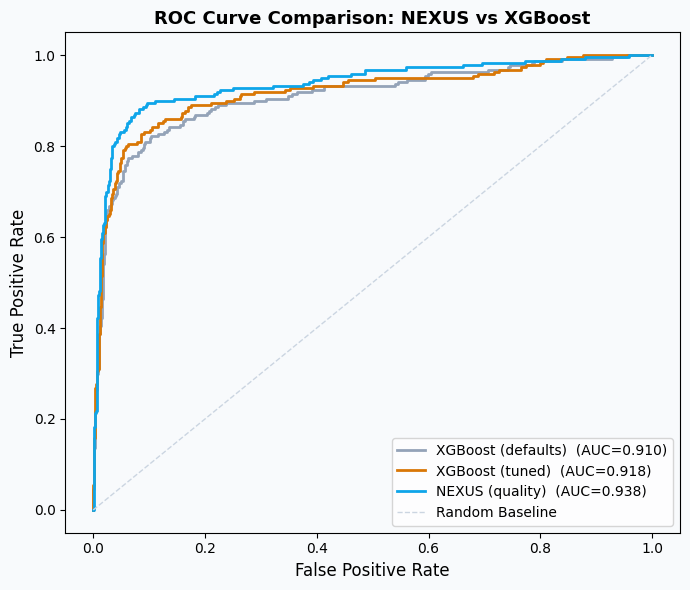

ROC chart saved.


In [23]:
fig, ax = plt.subplots(figsize=(7, 6))

colors = {"XGBoost (defaults)": "#94A3B8",
          "XGBoost (tuned)":    "#D97706",
          "NEXUS (quality)":    "#0EA5E9"}

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_holdout, r["proba"])
    ax.plot(fpr, tpr, label=f"{name}  (AUC={r['auc']:.3f})",
            color=colors[name], linewidth=2)

ax.plot([0, 1], [0, 1], "--", color="#CBD5E1", linewidth=1, label="Random Baseline")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve Comparison: NEXUS vs XGBoost", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("#F8FAFC")
plt.tight_layout()
plt.savefig("module_03_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROC chart saved.")


### Reading the Results Honestly

A few things worth discussing openly:

**Read the numbers in context.** On raw, cleaned data NEXUS leads. That is the headline, but it comes with a caveat: give XGBoost the same feature engineering and the gap narrows. NEXUS's edge is largest before the feature work — when you hand both models the same cleaned frame, NEXUS reads the categoricals directly while XGBoost still pays the encoding-and-imputation tax. AUC is one dimension; it is not the only one that matters in production.

**What the comparison does not capture:**
- NEXUS training runs in Fundamental's cloud. Your local machine is idle during the `fit()` call.
- Grid search tuning time is wall-clock time on your machine (or CI). For larger datasets, this scales badly.
- The XGBoost preprocessing pipeline is fragile at inference time: any new category value not seen during training requires the `handle_unknown` path in the encoder. NEXUS has no such encoder to reproduce.
- NEXUS model IDs give you versioned persistence for free. XGBoost requires `joblib.dump()` / `joblib.load()` and your own versioning discipline.

**Where XGBoost has the advantage:**
- Fully explainable feature importances via SHAP, including local per-record explanations and feature interactions — a richer explainability surface for compliance-driven domains. (NEXUS, by contrast, exposes only a flat *global* importance score per feature — no local or SHAP-style explanations.)
- No API dependency: runs entirely locally once trained.
- Mature ecosystem of tooling, monitoring, and integrations.

Neither model is universally right. But for teams that want to move fast on tabular problems without an ML engineering team, NEXUS closes the gap significantly — and because it takes the cleaned raw categoricals directly, there is no encoding pipeline to build, maintain, or reproduce at inference.

**End of the optional deep dive — everyone continues here.**

### Save Your Model IDs

We trained two NEXUS models in this module. Save both IDs -- you will use the enriched model in Module 4 for feature importance analysis.


In [24]:
print("=== Save These Model IDs ===")
print(f"Full borrower model:    {FULL_MODEL_ID}")
print(f"Enriched (all tables):  {ENRICHED_MODEL_ID}")

# Store the enriched model ID for Module 4
%store ENRICHED_MODEL_ID

=== Save These Model IDs ===
Full borrower model:    cdb25f3b-1547-47e5-9a9a-6b7a88de1717
Enriched (all tables):  f6639441-6381-46ee-99d3-8586469ef135
Stored 'ENRICHED_MODEL_ID' (str)


---

## Key Takeaways

**Part 1 — Categorical and date features**
NEXUS accepts categorical columns as-is — no encoder. Datetime columns are the one unsupported type, so the date becomes a single numeric feature (`account_tenure_days`) via one line of arithmetic. Cleaning and joins are optional but additive: less feature engineering, not zero.

**Part 2 — Multi-table enrichment**
Payment behavior, income, and credit assessment scores dramatically increase feature richness. The join pattern is standard pandas: sort by date, `drop_duplicates(keep="first")`, left merge. NEXUS handles the missing values from failed joins natively.

**Part 3 — Messy data**
NEXUS reads `Divorced` and `DIVORCED` as two different categories, so case variants and typos split the signal across extra categories. A light cleanup — `.str.strip().str.title()`, named typo fixes, dtype casts — folds the case variants together and lifts AUC. It is a partial pass: some typos and a float column remain, and that is fine. Cleaning is not required, but even an incomplete pass concentrates the signal.

**Part 4 — The benchmark**
On raw, cleaned data NEXUS led XGBoost, with no encoding pipeline and zero tuning. Give XGBoost the same feature engineering and the gap narrows — NEXUS's edge is largest before the feature work. The gap matters most for teams without dedicated feature-engineering infrastructure.

---

**What's Next — Module 4: Feature Importance**

Now that we have a rich, multi-table model, we want to understand which features are actually driving the predictions. Module 4 covers `get_feature_importance()` — global feature importance ranking, the cumulative-importance curve, and an importance-driven feature-trimming experiment that lets us train a leaner, almost-as-good model on a subset of features.